# Strategy Autoresearch Loop

This notebook auto-discovers the latest completed output directory from `scripts/run_strategy_autoresearch_loop.py` when one exists.
If no completed run exists yet, it still opens cleanly and tells you what artifacts are missing.


In [4]:
from __future__ import annotations

from collections import Counter
from decimal import Decimal
from html import escape
from pathlib import Path
import json

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    from IPython.display import HTML, Markdown, SVG, display
except ModuleNotFoundError:
    class HTML(str):
        pass

    class Markdown(str):
        pass

    class SVG(str):
        pass

    def display(*items: object) -> None:
        for item in items:
            print(item)

def _discover_run_root() -> Path | None:
    base = Path('/tmp/torghut-autoresearch-runs')
    if not base.exists():
        return None
    candidates = [
        path
        for path in base.iterdir()
        if path.is_dir()
        and (path / 'summary.json').exists()
        and (path / 'research_dossier.json').exists()
        and (path / 'history.jsonl').exists()
    ]
    if not candidates:
        return None
    return max(candidates, key=lambda item: item.stat().st_mtime)

def _read_json(path: Path, default: object) -> object:
    if not path.exists():
        return default
    return json.loads(path.read_text(encoding='utf-8'))

def _ordered_keys(rows: list[dict[str, object]]) -> list[str]:
    keys: list[str] = []
    for row in rows:
        for key in row.keys():
            if key not in keys:
                keys.append(key)
    return keys

def _display_rows(rows: list[dict[str, object]], *, columns: list[str] | None = None) -> None:
    rows = list(rows)
    if columns is None:
        columns = _ordered_keys(rows)
    if pd is not None:
        frame = pd.DataFrame(rows)
        if columns:
            frame = frame.reindex(columns=columns)
        display(frame)
        return
    if not columns:
        display(Markdown('_No rows_'))
        return
    header = ''.join(f'<th>{escape(str(column))}</th>' for column in columns)
    body_rows = []
    for row in rows:
        cells = ''.join(f'<td>{escape(str(row.get(column, "")))}</td>' for column in columns)
        body_rows.append(f'<tr>{cells}</tr>')
    if not body_rows:
        body_rows.append(f'<tr><td colspan="{len(columns)}"><em>No rows</em></td></tr>')
    table = (
        '<table style="border-collapse: collapse; width: 100%;">'
        f'<thead><tr>{header}</tr></thead>'
        f'<tbody>{"".join(body_rows)}</tbody>'
        '</table>'
    )
    display(HTML(table))

def _project_rows(rows: list[dict[str, object]], columns: list[str]) -> list[dict[str, object]]:
    return [{column: row.get(column) for column in columns} for row in rows]

def _to_float(value: object) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return 0.0

RUN_ROOT = _discover_run_root() or Path('/tmp/torghut-autoresearch-runs/<run-id>')
RUN_READY = all(
    (RUN_ROOT / name).exists()
    for name in ['summary.json', 'research_dossier.json', 'history.jsonl']
)
SUMMARY = _read_json(RUN_ROOT / 'summary.json', {}) if RUN_READY else {}
RESEARCH = _read_json(
    RUN_ROOT / 'research_dossier.json',
    {'program_id': '<none>', 'objective': {}, 'research_sources': []},
) if RUN_READY else {'program_id': '<none>', 'objective': {}, 'research_sources': []}
HISTORY = [
    json.loads(line)
    for line in (RUN_ROOT / 'history.jsonl').read_text(encoding='utf-8').splitlines()
    if line.strip()
] if RUN_READY else []

def _to_decimal(value: object) -> Decimal:
    return Decimal(str(value or '0'))

def _svg_line(points: list[Decimal], *, width: int = 720, height: int = 220, stroke: str = '#111827') -> str:
    if not points:
        return '<svg xmlns="http://www.w3.org/2000/svg" width="720" height="220"></svg>'
    numeric = [float(item) for item in points]
    minimum = min(numeric)
    maximum = max(numeric)
    spread = maximum - minimum or 1.0
    x_step = width / max(len(points) - 1, 1)
    def _y(value: float) -> float:
        return height - (((value - minimum) / spread) * (height - 20)) - 10
    coords = ' '.join(
        f'{index * x_step:.1f},{_y(value):.1f}'
        for index, value in enumerate(numeric)
    )
    return (
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">'
        f'<polyline fill="none" stroke="{stroke}" stroke-width="3" points="{coords}" />'
        '</svg>'
    )

display(Markdown(f'## Run Root\n`{RUN_ROOT}`'))
if not RUN_READY:
    display(Markdown('> No completed autoresearch run was found yet. Run `scripts/run_strategy_autoresearch_loop.py` to generate `summary.json`, `research_dossier.json`, and `history.jsonl`, or point `RUN_ROOT` at a completed run directory.'))
if pd is None:
    display(Markdown('> `pandas` is not installed in this kernel, so the notebook is using a lightweight HTML table renderer.'))
display(Markdown(f'## Program\n`{RESEARCH.get("program_id", "<none>")}`'))
_display_rows([RESEARCH.get('objective', {})])
_display_rows([SUMMARY.get('best_candidate') or {}])


## Run Root
`/tmp/torghut-autoresearch-runs/<run-id>`

> No completed autoresearch run was found yet. Run `scripts/run_strategy_autoresearch_loop.py` to generate `summary.json`, `research_dossier.json`, and `history.jsonl`, or point `RUN_ROOT` at a completed run directory.

> `pandas` is not installed in this kernel, so the notebook is using a lightweight HTML table renderer.

## Program
`<none>`

_No rows_

_No rows_

In [5]:
sources = []
for source in RESEARCH.get('research_sources', []):
    claims = '; '.join(claim.get('summary', '') for claim in source.get('claims', []))
    sources.append(
        {
            'source_id': source.get('source_id'),
            'title': source.get('title'),
            'published_at': source.get('published_at'),
            'url': source.get('url'),
            'claims': claims,
        }
    )
display(Markdown('## Research Sources'))
_display_rows(sources)

ledger_columns = [
    'experiment_index',
    'iteration',
    'family_template_id',
    'candidate_id',
    'status',
    'net_pnl_per_day',
    'active_day_ratio',
    'positive_day_ratio',
    'avg_filled_notional_per_day',
    'best_day_share',
    'max_drawdown',
    'pareto_tier',
    'mutation_label',
]
display(Markdown('## Experiment Ledger'))
_display_rows(_project_rows(HISTORY, ledger_columns), columns=ledger_columns)


## Research Sources

_No rows_

## Experiment Ledger

## Best Candidate Per Iteration

### Net PnL / Day

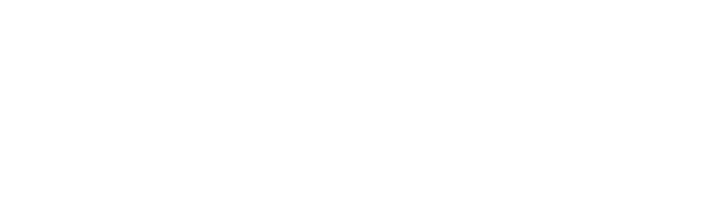

### Active Day Ratio

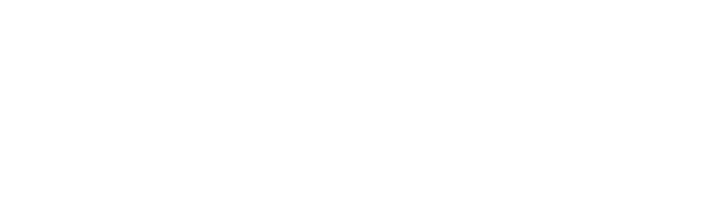

### Best-Day Share

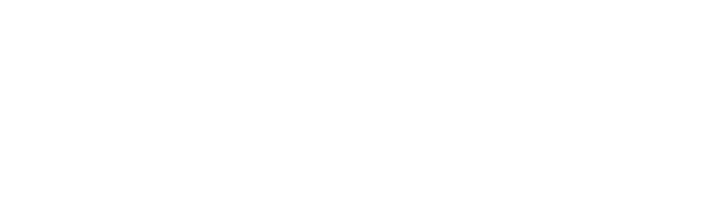

## Keep / Discard Mix

_No rows_

In [6]:
ranked = sorted(
    HISTORY,
    key=lambda row: (
        int(row.get('iteration') or 0),
        int(row.get('pareto_tier') or 0),
        -_to_float(row.get('net_pnl_per_day')),
    ),
)
best_by_iteration = []
seen_iterations: set[int] = set()
for row in ranked:
    iteration = int(row.get('iteration') or 0)
    if iteration in seen_iterations:
        continue
    seen_iterations.add(iteration)
    best_by_iteration.append(row)

best_columns = ['iteration', 'candidate_id', 'net_pnl_per_day', 'active_day_ratio', 'best_day_share', 'max_drawdown']
display(Markdown('## Best Candidate Per Iteration'))
_display_rows(_project_rows(best_by_iteration, best_columns), columns=best_columns)
display(Markdown('### Net PnL / Day'))
display(SVG(_svg_line([_to_decimal(item.get('net_pnl_per_day')) for item in best_by_iteration])))
display(Markdown('### Active Day Ratio'))
display(SVG(_svg_line([_to_decimal(item.get('active_day_ratio')) for item in best_by_iteration], stroke='#2563eb')))
display(Markdown('### Best-Day Share'))
display(SVG(_svg_line([_to_decimal(item.get('best_day_share')) for item in best_by_iteration], stroke='#dc2626')))

status_counts = Counter(item.get('status', '<missing>') for item in HISTORY)
display(Markdown('## Keep / Discard Mix'))
_display_rows([dict(status_counts)])
